Descargando datos para KO...


[*********************100%***********************]  2 of 2 completed



 ANÁLISIS CAPM
Beta estimado: 0.5316
Retorno esperado del mercado (anual): 10.48%
Costo del patrimonio (Ke - Retorno Requerido): 6.98%

ANÁLISIS DE CRECIMIENTO
Tasa de crecimiento fundamental (g): -1.26%

RESULTADOS DE VALORIZACIÓN
Dividendo proyectado (D1): $0.52
Valor intrínseco estimado (DDM): $6.36
Precio de mercado actual: $77.34
Potencial de revalorización (Upside/Downside): -91.78%


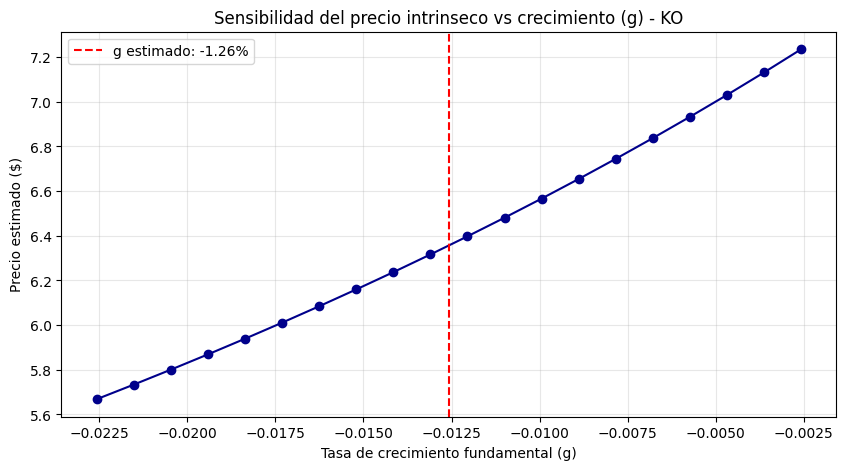

In [3]:
#PROYECTO: Corporate_Finance_and_Valuation
#Elaborado por: Ricardo Alexis Sifuentes Zevallos
#Objetivo: Estimación de valor intrínseco mediante CAPM y Gordon-Shapiro (DDM)

!pip install -q numpy pandas yfinance statsmodels matplotlib
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#1.EXTRACCIÓN DE DATOS (Caso de Estudio: Coca-Cola -KO)

ticker_stock = "KO"
ticker_market = "^GSPC" # S&P 500
start_date = "2015-01-01"

print(f"Descargando datos para {ticker_stock}...")
data = yf.download([ticker_stock, ticker_market], start=start_date)['Close']
returns = np.log(data / data.shift(1)).dropna()
returns.columns = ["Stock", "Market"]

#2.ESTIMACIÓN DEL RETORNO REQUERIDO (CAPM)
#Estimamos Beta (riesgo sistemático) mediante regresión OLS
Y = returns["Stock"]
X = sm.add_constant(returns["Market"])
capm_model = sm.OLS(Y, X).fit()

beta = capm_model.params["Market"]
rf = 0.03  #Tasa libre de riesgo anual (Proxy 10Y Treasury)
rm = returns["Market"].mean() * 252 # Retorno anualizado del mercado

#Costo del Patrimonio (Ke)
r_equity = rf + beta * (rm - rf)

print(f"\n ANÁLISIS CAPM")
print(f"Beta estimado: {beta:.4f}")
print(f"Retorno esperado del mercado (anual): {rm:.2%}")
print(f"Costo del patrimonio (Ke - Retorno Requerido): {r_equity:.2%}")

#3.ANÁLISIS HISTÓRICO DE DIVIDENDOS Y CRECIMIENTO (g)
#En lugar de suponer "g", lo estimamos con la tendencia histórica de dividendos
ticker = yf.Ticker(ticker_stock)
div_raw = ticker.dividends
div_annual = div_raw[div_raw.index >= start_date].resample("Y").sum()
div_annual = div_annual[div_annual > 0]

#Regresión logarítmica para hallar g: ln(Dt) = a + g*t
log_div = np.log(div_annual)
t = np.arange(len(log_div))
X_g = sm.add_constant(t)
model_g = sm.OLS(log_div.values, X_g).fit()

g_fundamental = np.exp(model_g.params[1]) - 1

print(f"\nANÁLISIS DE CRECIMIENTO")
print(f"Tasa de crecimiento fundamental (g): {g_fundamental:.2%}")

#4.VALORIZACIÓN FUNDAMENTAL (GORDON-SHAPIRO)
d0 = div_annual.values[-1] #Último dividendo pagado
d1 = d0 * (1 + g_fundamental) #Dividendo esperado año 1

#Modelo: P0 = D1 / (r - g)
if r_equity > g_fundamental:
    intrinsic_price = d1 / (r_equity - g_fundamental)
    market_price = ticker.history(period="1d")["Close"].iloc[0]
    upside = (intrinsic_price / market_price) - 1
else:
    intrinsic_price = np.nan
    print("Error: r < g. El modelo Gordon-Shapiro no converge.")

print(f"\nRESULTADOS DE VALORIZACIÓN")
print(f"Dividendo proyectado (D1): ${d1:.2f}")
print(f"Valor intrínseco estimado (DDM): ${intrinsic_price:.2f}")
print(f"Precio de mercado actual: ${market_price:.2f}")
print(f"Potencial de revalorización (Upside/Downside): {upside:.2%}")

#5. ANÁLISIS DE SENSIBILIDAD
g_range = np.linspace(g_fundamental - 0.01, g_fundamental + 0.01, 20)
sens_prices = [d1 / (r_equity - gi) for gi in g_range]

plt.figure(figsize=(10, 5))
plt.plot(g_range, sens_prices, color='darkblue', marker='o')
plt.axvline(g_fundamental, color='red', linestyle='--', label=f'g estimado: {g_fundamental:.2%}')
plt.title(f"Sensibilidad del precio intrinseco vs crecimiento (g) - {ticker_stock}")
plt.xlabel("Tasa de crecimiento fundamental (g)")
plt.ylabel("Precio estimado ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()